# 01 Exploration

Week 2 exploratory data analysis for predicting California residential single-family property `ClosePrice` using historical CRMLS sold property data.

This notebook focuses on four goals:

1. Combine the monthly raw extracts into one analysis-ready table.
2. Apply the project scope filter and remove obvious duplicate listings.
3. Check data quality, missingness, and suspicious values.
4. Build a first-pass understanding of price levels, trends, and important features.


In [27]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.2f}".format)
plt.style.use("ggplot")


## Load Monthly Raw Data

The repository now contains monthly sold-property extracts in `data/raw/`. For Week 2 we will load every available file, tag each row with its source month, and combine them into a single raw DataFrame.


In [28]:
raw_dir = Path("../data/raw")
raw_files = sorted(raw_dir.glob("CRMLSSold*.csv"))

if not raw_files:
    raise FileNotFoundError("No raw CSV files were found in ../data/raw")

frames = []
for file_path in raw_files:
    month_tag = file_path.stem.replace("CRMLSSold", "")
    monthly_df = pd.read_csv(file_path, low_memory=False)
    monthly_df["source_file"] = file_path.name
    monthly_df["source_month"] = month_tag
    frames.append(monthly_df)

raw_df = pd.concat(frames, ignore_index=True)

print(f"Loaded {len(raw_files)} monthly files")
print(f"Raw shape: {raw_df.shape}")
display(pd.DataFrame({"file": [p.name for p in raw_files]}))


Loaded 7 monthly files
Raw shape: (143492, 80)


,file
0,CRMLSSold202511.csv
1,CRMLSSold202512.csv
2,CRMLSSold202601.csv
3,CRMLSSold202602.csv
4,CRMLSSold202603.csv
5,CRMLSSold202604.csv
6,CRMLSSold202605.csv


## Apply Project Scope And Clean Core Fields

Project scope from the repository notes:

- `PropertyType == "Residential"`
- `PropertySubType == "SingleFamilyResidence"`

Because the monthly extracts can overlap slightly, we also remove duplicate listing records using `ListingKeyNumeric` when available, falling back to other listing identifiers if needed.


In [29]:
scoped_df = raw_df.loc[
    (raw_df["PropertyType"] == "Residential")
    & (raw_df["PropertySubType"] == "SingleFamilyResidence")
].copy()

scoped_df["dedupe_key"] = (
    scoped_df["ListingKeyNumeric"].astype("string").fillna("").str.strip()
)

missing_dedupe_key = scoped_df["dedupe_key"].eq("")
scoped_df.loc[missing_dedupe_key, "dedupe_key"] = (
    scoped_df.loc[missing_dedupe_key, "ListingId"]
    .astype("string")
    .fillna("")
    .str.strip()
)

still_missing_dedupe_key = scoped_df["dedupe_key"].eq("")
scoped_df.loc[still_missing_dedupe_key, "dedupe_key"] = (
    scoped_df.loc[still_missing_dedupe_key, "ListingKey"]
    .astype("string")
    .fillna("")
    .str.strip()
)

before_dedup = len(scoped_df)
analysis_df = scoped_df.drop_duplicates(subset="dedupe_key", keep="first").copy()

numeric_cols = [
    "ClosePrice",
    "ListPrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "DaysOnMarket",
]

for col in numeric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

analysis_df["CloseDate"] = pd.to_datetime(analysis_df["CloseDate"], errors="coerce")
analysis_df["source_month"] = pd.to_datetime(
    analysis_df["source_month"], format="%Y%m", errors="coerce"
)
analysis_df["sale_to_list_ratio"] = analysis_df["ClosePrice"] / analysis_df["ListPrice"]
analysis_df["log_close_price"] = np.log1p(analysis_df["ClosePrice"])
analysis_df["log_living_area"] = np.log1p(analysis_df["LivingArea"])
analysis_df["close_month"] = (
    analysis_df["CloseDate"].dt.to_period("M").dt.to_timestamp()
)

print(f"Scoped rows before dedupe: {before_dedup:,}")
print(f"Rows after dedupe: {len(analysis_df):,}")
print(f"Removed duplicate rows: {before_dedup - len(analysis_df):,}")


Scoped rows before dedupe: 71,466
Rows after dedupe: 71,414
Removed duplicate rows: 52


## Dataset Snapshot

A quick overview helps confirm that the scope filter worked and that the time coverage looks reasonable before deeper analysis.


In [30]:
overview = pd.DataFrame(
    {
        "metric": [
            "raw_rows",
            "scoped_rows_before_dedup",
            "rows_after_dedup",
            "column_count",
            "closeprice_missing",
            "closedate_missing",
        ],
        "value": [
            len(raw_df),
            before_dedup,
            len(analysis_df),
            analysis_df.shape[1],
            int(analysis_df["ClosePrice"].isna().sum()),
            int(analysis_df["CloseDate"].isna().sum()),
        ],
    }
)

display(overview)

display(
    analysis_df.groupby("source_month", dropna=False)
    .size()
    .rename("row_count")
    .reset_index()
    .sort_values("source_month")
)

analysis_df.head()


,metric,value
0,raw_rows,143492
1,scoped_rows_before_dedup,71466
2,rows_after_dedup,71414
3,column_count,85
4,closeprice_missing,0
5,closedate_missing,0


,source_month,row_count
0,2025-11-01,9739
1,2025-12-01,10440
2,2026-01-01,7483
3,2026-02-01,8545
4,2026-03-01,11166
5,2026-04-01,12024
6,2026-05-01,12017


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal,AssociationFeeFrequency,AboveGradeFinishedArea,ListingKeyNumeric,MLSAreaMajor,TaxAnnualAmount,CountyOrParish,MlsStatus,ElementarySchool,AttachedGarageYN,ParkingTotal,BuilderName,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,StreetNumberNumeric,ListingId,BathroomsTotalInteger,City,TaxYear,BuildingAreaTotal,BedroomsTotal,ContractStatusChangeDate,ElementarySchoolDistrict,CoBuyerAgentFirstName,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,BusinessType,StateOrProvince,CoveredSpaces,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,source_file,source_month,dedupe_key,sale_to_list_ratio,log_close_price,log_living_area,close_month
0,OrangeCounty,OrangeCounty,"Carpet,Tile",False,NaN,NaN,False,1250000.00,1147233684,mattkanoudi@gmail.com,2025-11-30,1250000.00,Matthew,Kanoudi,33.68,-118.00,8441 Tern Circle,Residential,1027.00,1250000.00,0,The L3,The L3,The L3,Matthew Kanoudi,Tim,Roach,OCPIRRJAM,Jamie,Pirritano,NaN,NaN,NaN,1147233684,14 - South Huntington Beach,NaN,Orange,Closed,NaN,True,2.00,NaN,SingleFamilyResidence,0.14,Pacific Sands (Dean/Broc) (PSAN),OrangeCounty,1961.00,8441.00,OC25233234,2.00,Huntington Beach,NaN,NaN,3.00,2025-11-30,NaN,Brett,2025-11-30,2025-11-30,NaN,NaN,CA,NaN,NaN,False,1.00,NaN,One,NaN,5913.00,3.00,False,2.00,Huntington Beach Union High,92646,0.00,5913.00,NaN,CRMLSSold202511.csv,2025-11-01,1147233684,1.00,14.04,6.94,2025-11-01
1,Mlslistings,Mlslistings,Carpet,False,NaN,NaN,NaN,NaN,1147228247,babeksells@gmail.com,2025-11-20,2299995.00,Babek,Sandhar,37.26,-121.93,15149 Woodard Road,Residential,1129.00,2299995.00,0,Realty One Group Infinity,Realty One Group Infinity,Realty One Group Infinity,Babek Sandhar,Efrain,Fernandez,ML5096216,Babek,Sandhar,NaN,NaN,NaN,1147228247,699 - Not Defined,NaN,Santa Clara,Closed,NaN,True,2.00,NaN,SingleFamilyResidence,0.42,NaN,Mlslistings,1949.00,15149.00,ML82028433,1.00,San Jose,NaN,NaN,3.00,2025-11-20,NaN,Efrain,2025-11-20,2025-11-20,NaN,NaN,CA,NaN,NaN,True,NaN,NaN,NaN,NaN,18432.00,NaN,False,2.00,Other,95124,NaN,18432.00,NaN,CRMLSSold202511.csv,2025-11-01,1147228247,1.00,14.65,7.03,2025-11-01
2,PacificSouthwest,PacificSouthwest,NaN,False,NaN,NaN,False,799900.00,1147223143,rigosd@gmail.com,2025-11-26,810000.00,RJ,Leal,32.56,-117.06,3053 Tequila Way,Residential,1619.00,799900.00,0,"Leal Real Estate Group, Inc",1st Choice Home Team,NaN,RJ Leal,NaN,NaN,820027,Jill,Huhn,NaN,NaN,NaN,1147223143,92173 - San Ysidro,NaN,San Diego,Closed,NaN,True,5.00,NaN,SingleFamilyResidence,0.12,NaN,PacificSouthwest,1978.00,3053.00,PTP2508838,3.00,San Ysidro,NaN,NaN,4.00,2025-11-26,NaN,Lori,2025-11-03,2025-09-15,NaN,NaN,CA,NaN,NaN,True,2.00,NaN,Two,NaN,5300.00,0.00,NaN,2.00,San Diego Unified,92173,0.00,5300.00,NaN,CRMLSSold202511.csv,2025-11-01,1147223143,1.01,13.60,7.39,2025-11-01
3,PacificSouthwest,PacificSouthwest,NaN,False,NaN,NaN,False,925000.00,1147209231,conchita@conchitalopez.com,2025-11-17,925000.00,Conchita,Lopez,32.58,-117.02,1182 Sea Reef Drive,Residential,2872.00,925000.00,0,Finest City Homes,Finest City Homes,NaN,Conchita Lopez,NaN,NaN,803477,Conchita,Lopez,NaN,Monthly,NaN,1147209231,92154 - Otay Mesa,NaN,San Diego,Closed,NaN,True,3.00,NaN,SingleFamilyResidence,0.12,NaN,PacificSouthwest,2000.00,1182.00,PTP2508827,3.00,San Diego,NaN,NaN,5.00,2025-11-17,NaN,NaN,2025-11-01,2025-11-01,NaN,NaN,CA,NaN,NaN,True,2.00,NaN,Two,NaN,5272.00,1.00,NaN,3.00

## Missingness Review

The target and most modeling fields are present for nearly every row. This section quantifies the small set of fields that will need attention before modeling.


In [31]:
key_fields = [
    "ClosePrice",
    "ListPrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "City",
    "PostalCode",
    "Latitude",
    "Longitude",
    "CloseDate",
    "DaysOnMarket",
]

missing_summary = (
    analysis_df[key_fields]
    .isna()
    .sum()
    .rename("missing_count")
    .reset_index()
    .rename(columns={"index": "column"})
)
missing_summary["missing_pct"] = missing_summary["missing_count"] / len(analysis_df)
missing_summary = missing_summary.sort_values(
    ["missing_pct", "column"], ascending=[False, True]
)

display(missing_summary)


,column,missing_count,missing_pct
5,LotSizeSquareFeet,1227,0.02
6,YearBuilt,41,0.00
2,LivingArea,34,0.00
7,City,14,0.00
9,Latitude,9,0.00
10,Longitude,9,0.00
4,BathroomsTotalInteger,1,0.00
8,PostalCode,1,0.00
3,BedroomsTotal,0,0.00
11,CloseDate,0,0.00


## Numeric Summary Statistics

The price target is strongly right-skewed, so both raw and log-scale views will matter later. We also summarize size and market-timing variables that are likely to matter in modeling.


In [32]:
numeric_summary_cols = [
    "ClosePrice",
    "ListPrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "DaysOnMarket",
]

summary_table = (
    analysis_df[numeric_summary_cols]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])
    .T
)
summary_table = summary_table.rename(columns={"50%": "median"})
display(summary_table)


,count,mean,std,min,25%,median,75%,95%,99%,max
ClosePrice,71414.00,1340376.32,7389736.53,1.75,620000.00,890000.00,1420000.00,3200000.00,6500000.00,796000000.00
ListPrice,71414.00,1265812.59,1513250.22,8000.00,624319.75,889900.00,1399000.00,3199000.00,6595000.00,65000000.00
LivingArea,71380.00,2054.10,1038.70,0.00,1387.00,1825.00,2451.00,3837.00,5686.00,31068.00
BedroomsTotal,71414.00,3.50,0.97,0.00,3.00,3.00,4.00,5.00,6.00,22.00
BathroomsTotalInteger,71413.00,2.64,1.13,0.00,2.00,2.00,3.00,5.00,6.00,23.00
LotSizeSquareFeet,70187.00,481714.32,21232639.97,0.00,5663.00,7260.00,10454.00,52707.60,307157.08,1938942720.00
YearBuilt,71373.00,1976.21,27.72,1801.00,1956.00,1977.00,1999.00,2023.00,2025.00,2026.00
DaysOnMarket,71414.00,41.75,56.98,-265.00,8.00,20.00,54.00,154.00,263.00,2177.00


## Suspicious Values And Data Quality Flags

A few values look unusual enough to flag for follow-up before modeling:

- extremely small sale prices
- zero living area
- negative days on market
- very large lot sizes and close prices

We are not dropping them yet in Week 2, but we want to document them clearly.


In [33]:
quality_flags = pd.DataFrame(
    {
        "flag": [
            "close_price_le_1000",
            "living_area_eq_0",
            "living_area_le_300",
            "days_on_market_lt_0",
            "year_built_lt_1900",
            "lot_size_eq_0",
        ],
        "row_count": [
            int((analysis_df["ClosePrice"] <= 1000).sum()),
            int((analysis_df["LivingArea"] == 0).sum()),
            int((analysis_df["LivingArea"] <= 300).sum()),
            int((analysis_df["DaysOnMarket"] < 0).sum()),
            int((analysis_df["YearBuilt"] < 1900).sum()),
            int((analysis_df["LotSizeSquareFeet"] == 0).sum()),
        ],
    }
)

display(quality_flags)

suspicious_rows = analysis_df.loc[
    (analysis_df["ClosePrice"] <= 1000)
    | (analysis_df["LivingArea"] == 0)
    | (analysis_df["DaysOnMarket"] < 0),
    [
        "ListingId",
        "UnparsedAddress",
        "City",
        "CloseDate",
        "ClosePrice",
        "ListPrice",
        "LivingArea",
        "DaysOnMarket",
        "source_file",
    ],
].sort_values(["ClosePrice", "LivingArea"], ascending=[True, True])

display(suspicious_rows.head(20))


,flag,row_count
0,close_price_le_1000,2
1,living_area_eq_0,20
2,living_area_le_300,26
3,days_on_market_lt_0,6
4,year_built_lt_1900,116
5,lot_size_eq_0,47


,ListingId,UnparsedAddress,City,CloseDate,ClosePrice,ListPrice,LivingArea,DaysOnMarket,source_file
50217,219137367DA,600 Gold Canyon Drive,Palm Desert,2026-01-30,1.75,1749000.00,3513.00,96,CRMLSSold202601.csv
114423,41121689,23 Cloverbrook Ct,Oakley,2026-04-29,685.00,913655.00,2980.00,53,CRMLSSold202604.csv
132672,CV26060531,10803 Larch Avenue,Bloomington,2026-05-08,365000.00,380000.00,840.00,-4,CRMLSSold202605.csv
106806,260004946SD,23930 Elsinore Lane,Menifee,2026-04-24,385000.00,379000.00,0.00,17,CRMLSSold202604.csv
69473,SW25250711,1457 Angelus Hill,Hemet,2026-02-09,445000.00,429900.00,1774.00,-14,CRMLSSold202602.csv
39407,IV24237150,17101 Baywood Way,Victorville,2025-12-03,455000.00,455000.00,2189.00,-4,CRMLSSold202512.csv
117508,IV25264760,1425 39th E,San Bernardino,2026-04-28,530000.00,530000.00,2143.00,-39,CRMLSSold202604.csv
44412,41118717,1346 Manor Dr,San Pablo,2026-01-16,540000.00,530000.00,0.00,13,CRMLSSold202601.csv
19036,SB24042834,4933 7th Avenue,Los Angeles,2025-11-06,560000.00,675000.00,1333.00,-65,CRMLSSold202511.csv
19051,SR24008510,502 N Glenn Place,Ontario,2025-11-06,615000.00,600000.00,1189.00,-265,CRMLSSold202511.csv


## Distribution Plots

We start with univariate views of the target and several important features. `ClosePrice` is plotted on both the raw and log scales because the luxury tail is large enough to compress the rest of the market on the raw scale.


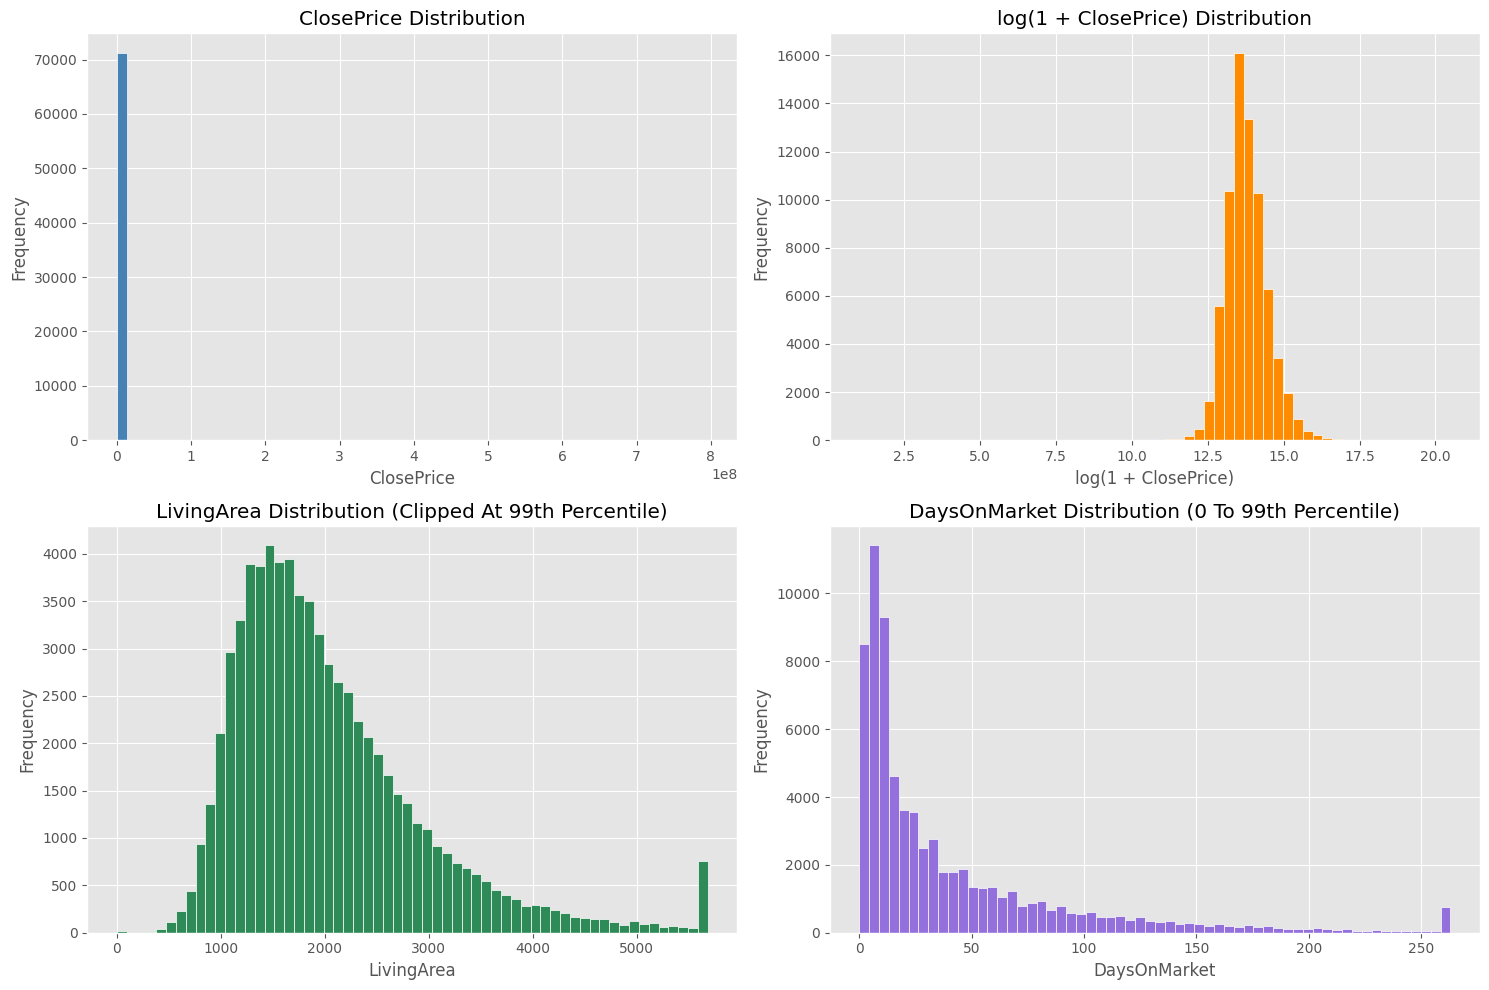

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

analysis_df["ClosePrice"].dropna().plot(
    kind="hist", bins=60, ax=axes[0, 0], color="steelblue", edgecolor="white"
)
axes[0, 0].set_title("ClosePrice Distribution")
axes[0, 0].set_xlabel("ClosePrice")

analysis_df["log_close_price"].dropna().plot(
    kind="hist", bins=60, ax=axes[0, 1], color="darkorange", edgecolor="white"
)
axes[0, 1].set_title("log(1 + ClosePrice) Distribution")
axes[0, 1].set_xlabel("log(1 + ClosePrice)")

analysis_df["LivingArea"].clip(
    upper=analysis_df["LivingArea"].quantile(0.99)
).dropna().plot(
    kind="hist", bins=60, ax=axes[1, 0], color="seagreen", edgecolor="white"
)
axes[1, 0].set_title("LivingArea Distribution (Clipped At 99th Percentile)")
axes[1, 0].set_xlabel("LivingArea")

analysis_df["DaysOnMarket"].clip(
    lower=0, upper=analysis_df["DaysOnMarket"].quantile(0.99)
).dropna().plot(
    kind="hist", bins=60, ax=axes[1, 1], color="mediumpurple", edgecolor="white"
)
axes[1, 1].set_title("DaysOnMarket Distribution (0 To 99th Percentile)")
axes[1, 1].set_xlabel("DaysOnMarket")

plt.tight_layout()
plt.show()


## Monthly Trend Review

Even with only seven monthly extracts, it is useful to check whether median sale price is stable or drifting upward over time.


,source_month,transaction_count,median_close_price,mean_close_price
0,2025-11-01,9739,875000.00,1338764.04
1,2025-12-01,10440,860000.00,1196100.92
2,2026-01-01,7483,852000.00,1280972.15
3,2026-02-01,8545,880000.00,1393356.26
4,2026-03-01,11166,898000.00,1333306.96
5,2026-04-01,12024,923000.00,1503017.05
6,2026-05-01,12017,930000.00,1310176.51


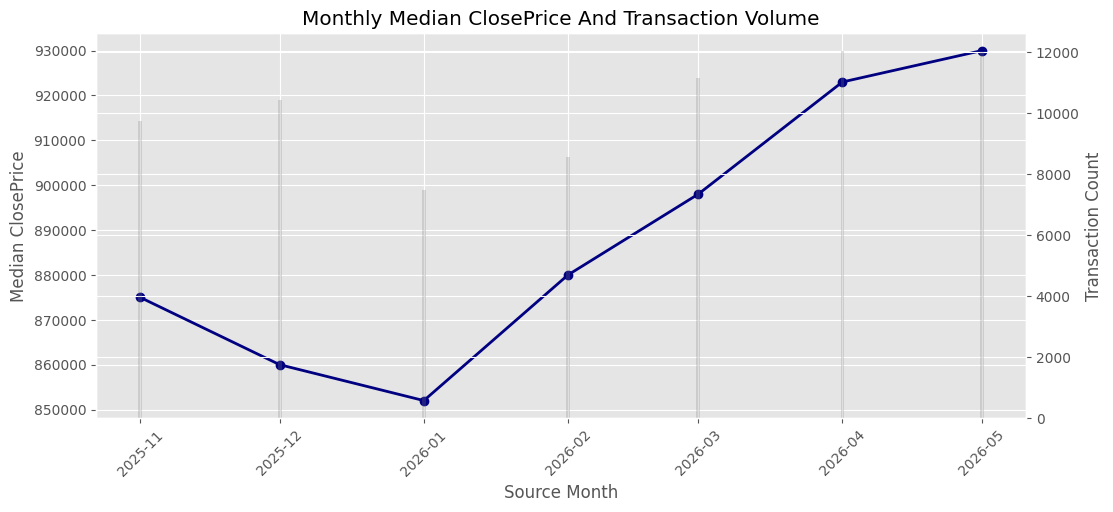

In [35]:
monthly_price_stats = (
    analysis_df.groupby("source_month")
    .agg(
        transaction_count=("ClosePrice", "size"),
        median_close_price=("ClosePrice", "median"),
        mean_close_price=("ClosePrice", "mean"),
    )
    .reset_index()
    .sort_values("source_month")
)

display(monthly_price_stats)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(
    monthly_price_stats["source_month"],
    monthly_price_stats["median_close_price"],
    marker="o",
    linewidth=2,
    color="navy",
    label="Median ClosePrice",
)
ax2.bar(
    monthly_price_stats["source_month"],
    monthly_price_stats["transaction_count"],
    alpha=0.25,
    color="gray",
    label="Transaction Count",
)

ax1.set_title("Monthly Median ClosePrice And Transaction Volume")
ax1.set_xlabel("Source Month")
ax1.set_ylabel("Median ClosePrice")
ax2.set_ylabel("Transaction Count")
ax1.tick_params(axis="x", rotation=45)
plt.show()


## Feature Relationships

The two most important first-pass relationships to check are:

- sale price vs. list price
- sale price vs. living area

Raw-scale correlations are muted by outliers, so we also calculate correlations on log-transformed variables.


,metric,value
0,"corr(ClosePrice, ListPrice)",0.18
1,"corr(ClosePrice, LivingArea)",0.12
2,"corr(ClosePrice, DaysOnMarket)",0.01
3,"corr(log_close_price, log_living_area)",0.55


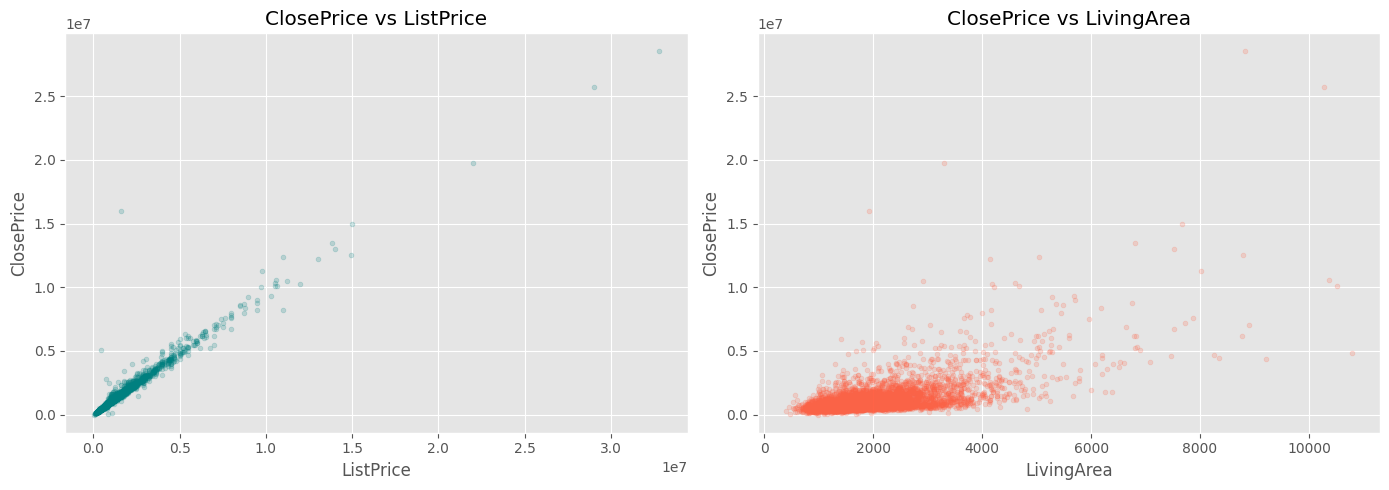

In [36]:
plot_df = analysis_df[
    [
        "ClosePrice",
        "ListPrice",
        "LivingArea",
        "log_close_price",
        "log_living_area",
        "DaysOnMarket",
    ]
].dropna()
plot_sample = plot_df.sample(min(5000, len(plot_df)), random_state=42)

corr_table = pd.DataFrame(
    {
        "metric": [
            "corr(ClosePrice, ListPrice)",
            "corr(ClosePrice, LivingArea)",
            "corr(ClosePrice, DaysOnMarket)",
            "corr(log_close_price, log_living_area)",
        ],
        "value": [
            plot_df["ClosePrice"].corr(plot_df["ListPrice"]),
            plot_df["ClosePrice"].corr(plot_df["LivingArea"]),
            plot_df["ClosePrice"].corr(plot_df["DaysOnMarket"]),
            plot_df["log_close_price"].corr(plot_df["log_living_area"]),
        ],
    }
)

display(corr_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    plot_sample["ListPrice"], plot_sample["ClosePrice"], alpha=0.2, s=12, color="teal"
)
axes[0].set_title("ClosePrice vs ListPrice")
axes[0].set_xlabel("ListPrice")
axes[0].set_ylabel("ClosePrice")

axes[1].scatter(
    plot_sample["LivingArea"],
    plot_sample["ClosePrice"],
    alpha=0.2,
    s=12,
    color="tomato",
)
axes[1].set_title("ClosePrice vs LivingArea")
axes[1].set_xlabel("LivingArea")
axes[1].set_ylabel("ClosePrice")

plt.tight_layout()
plt.show()


## Segment Analysis

Bedrooms, bathrooms, and location all show clear price segmentation. This is useful for feature engineering later because it suggests both structural and geographic variables will matter.


,BedroomsTotal,transaction_count,median_close_price
0,0.00,31,675000.00
1,1.00,429,440000.00
2,2.00,8112,635000.00
3,3.00,29742,814950.00
4,4.00,23877,1030000.00
5,5.00,7529,1365000.00
6,6.00,1329,1800000.00
7,7.00,263,2219000.00
8,8.00,63,1749000.00


,BathroomsTotalInteger,transaction_count,median_close_price
0,1.00,6465,645000.00
1,2.00,30448,780000.00
2,3.00,23991,995000.00
3,4.00,6108,1578838.50
4,5.00,2660,2400000.00
5,6.00,1037,3450000.00
6,7.00,386,4700000.00
7,8.00,156,6273125.00
8,9.00,59,9100000.00
9,10.00,38,9002500.00


,City,transaction_count,median_close_price,mean_close_price
460,Los Angeles,2946,1350000.00,1876880.17
723,San Diego,2480,1200000.00,2031983.96
698,Riverside,1094,680000.00,744460.96
729,San Jose,1033,1649000.00,1792161.34
577,Oakland,908,950000.00,1108392.99
491,Menifee,847,575000.00,568763.28
454,Long Beach,715,1005000.00,1161944.53
421,Lancaster,687,469900.00,485588.84
539,Murrieta,644,702000.00,800406.91
872,Victorville,642,430000.00,1172369.69


,City,transaction_count,median_close_price,mean_close_price
74,Beverly Hills,145,5300000.00,8482298.12
552,Newport Beach,245,4280000.00,5244321.71
755,Santa Monica,115,3850000.00,4403789.92
607,Palo Alto,106,3650000.00,4557749.03
388,La Jolla,141,3610000.00,4458326.06
478,Manhattan Beach,141,3502000.00,4366482.04
400,Laguna Beach,135,3185000.00,4269799.13
202,Dana Point,131,3068000.00,4144042.01
463,Los Gatos,111,2600000.00,2983735.32
818,Sunnyvale,134,2570000.00,2624321.63


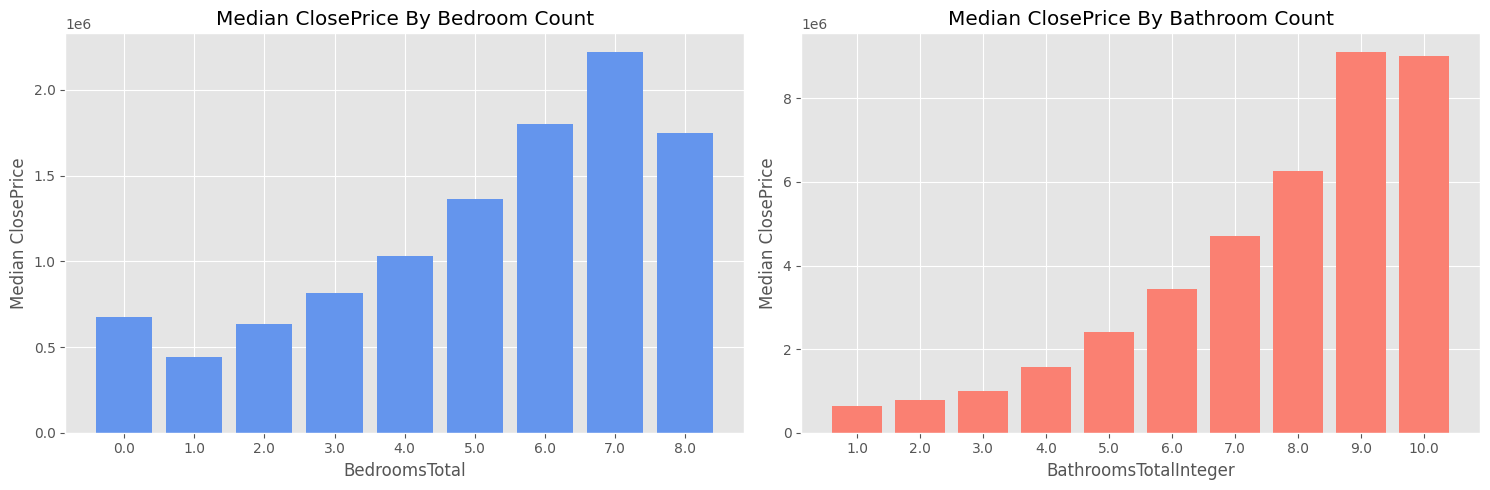

In [37]:
bedroom_price = (
    analysis_df.groupby("BedroomsTotal")
    .agg(
        transaction_count=("ClosePrice", "size"),
        median_close_price=("ClosePrice", "median"),
    )
    .query("transaction_count >= 30")
    .reset_index()
    .sort_values("BedroomsTotal")
)

bathroom_price = (
    analysis_df.groupby("BathroomsTotalInteger")
    .agg(
        transaction_count=("ClosePrice", "size"),
        median_close_price=("ClosePrice", "median"),
    )
    .query("transaction_count >= 30")
    .reset_index()
    .sort_values("BathroomsTotalInteger")
)

city_volume = (
    analysis_df.groupby("City")
    .agg(
        transaction_count=("ClosePrice", "size"),
        median_close_price=("ClosePrice", "median"),
        mean_close_price=("ClosePrice", "mean"),
    )
    .reset_index()
    .sort_values("transaction_count", ascending=False)
)

top_cities_by_volume = city_volume.head(12)
high_value_cities = (
    city_volume.loc[city_volume["transaction_count"] >= 100]
    .sort_values("median_close_price", ascending=False)
    .head(10)
)

display(bedroom_price)
display(bathroom_price)
display(top_cities_by_volume)
display(high_value_cities)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(
    bedroom_price["BedroomsTotal"].astype(str),
    bedroom_price["median_close_price"],
    color="cornflowerblue",
)
axes[0].set_title("Median ClosePrice By Bedroom Count")
axes[0].set_xlabel("BedroomsTotal")
axes[0].set_ylabel("Median ClosePrice")

axes[1].bar(
    bathroom_price["BathroomsTotalInteger"].astype(str),
    bathroom_price["median_close_price"],
    color="salmon",
)
axes[1].set_title("Median ClosePrice By Bathroom Count")
axes[1].set_xlabel("BathroomsTotalInteger")
axes[1].set_ylabel("Median ClosePrice")

plt.tight_layout()
plt.show()


## Sale-To-List Ratio And Spatial Coverage

This ratio is a simple way to understand whether homes usually sold below, at, or above list price. A quick geographic scatter also confirms that latitude and longitude coverage is broad enough to support location-based feature engineering later.


,count,mean,std,min,25%,median,75%,95%,max
sale_to_list_ratio,71414.00,1.12,10.40,0.00,0.97,1.00,1.02,1.11,1024.67


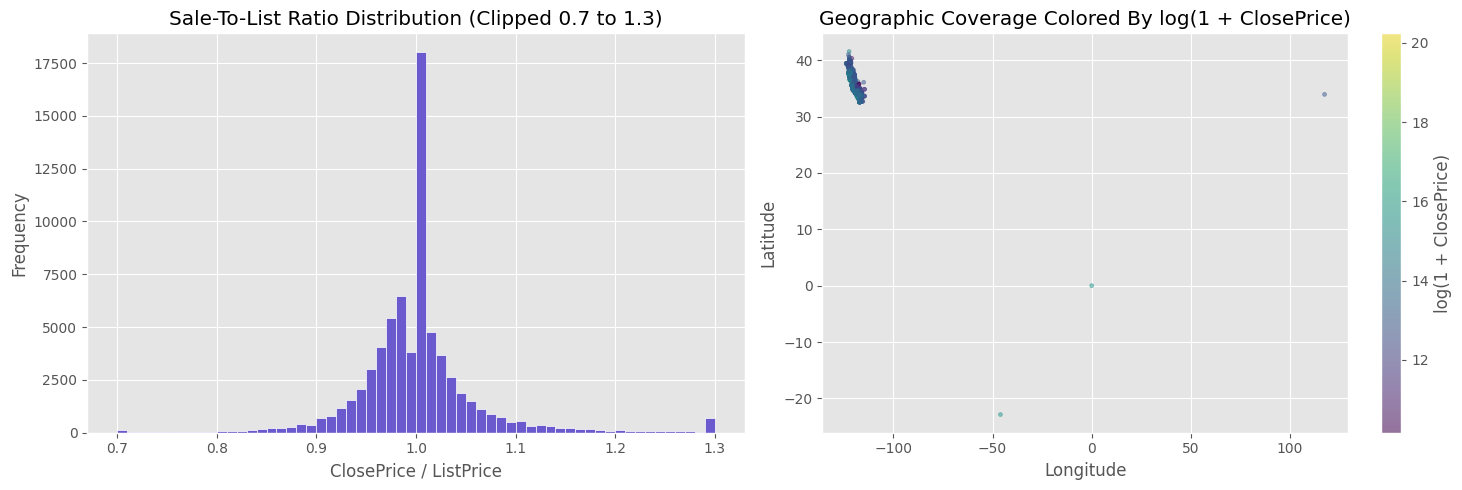

In [38]:
ratio_summary = (
    analysis_df["sale_to_list_ratio"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95])
    .to_frame()
    .T
)
ratio_summary = ratio_summary.rename(columns={"50%": "median"})
display(ratio_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

analysis_df["sale_to_list_ratio"].clip(lower=0.7, upper=1.3).dropna().plot(
    kind="hist", bins=60, ax=axes[0], color="slateblue", edgecolor="white"
)
axes[0].set_title("Sale-To-List Ratio Distribution (Clipped 0.7 to 1.3)")
axes[0].set_xlabel("ClosePrice / ListPrice")

map_sample = (
    analysis_df[["Longitude", "Latitude", "log_close_price"]]
    .dropna()
    .sample(
        min(
            5000,
            analysis_df[["Longitude", "Latitude", "log_close_price"]].dropna().shape[0],
        ),
        random_state=42,
    )
)
scatter = axes[1].scatter(
    map_sample["Longitude"],
    map_sample["Latitude"],
    c=map_sample["log_close_price"],
    cmap="viridis",
    s=8,
    alpha=0.5,
)
axes[1].set_title("Geographic Coverage Colored By log(1 + ClosePrice)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
plt.colorbar(scatter, ax=axes[1], label="log(1 + ClosePrice)")

plt.tight_layout()
plt.show()


## Week 2 Findings

Key takeaways from this first EDA pass:

1. After applying the project scope and removing duplicate listing IDs, the analysis set contains **71,414** residential single-family sold listings.
2. The target is highly right-skewed. Median `ClosePrice` is about **$890,000**, while the mean is about **$1.34M**, so log-based modeling and robust error analysis will be important.
3. Core modeling fields are in good shape. `ClosePrice` and `ListPrice` have no missing values, and most structural fields have very low missingness. `LotSizeSquareFeet` is the only notable gap at about **1.7%** missing.
4. There are a few obvious anomalies to handle before modeling, including **2** sale prices at or below `$1,000`, **20** records with zero `LivingArea`, and **6** negative `DaysOnMarket` values.
5. Median sale price appears to rise across the available monthly extracts, from roughly **$875k** in `2025-11` to about **$930k** in `2026-05`.
6. `ListPrice` is extremely informative for predicting `ClosePrice`, while `LivingArea` becomes much more useful once both variables are viewed on the log scale.
7. Price segmentation by structure and geography is strong. Higher bedroom and bathroom counts generally correspond to higher median prices, and high-volume premium cities such as **Beverly Hills**, **Newport Beach**, and **Santa Monica** sit far above the statewide middle.
8. The sale-to-list ratio is centered around **1.00**, which suggests many homes sold near list price, but the upper tail shows a meaningful subset of competitive over-list transactions.

### Suggested Week 3 Follow-Up

- Decide how to handle outliers and suspicious records.
- Create a reusable cleaned feature set in `src/`.
- Engineer date, location, and price-per-square-foot features.
- Build a baseline model and evaluate it against a holdout split.


## Export Reusable Dataset

Save the scoped and deduplicated dataset so later notebooks can build on the same Week 1 output instead of repeating the raw-data setup.


In [39]:
output_dir = Path("../outputs")
output_dir.mkdir(parents=True, exist_ok=True)

eda_output = output_dir / "eda_scoped_base.csv"
analysis_df.to_csv(eda_output, index=False)

print(f"Saved scoped Week 1 dataset to {eda_output}")
print(f"Rows saved: {len(analysis_df):,}")
print(f"Columns saved: {analysis_df.shape[1]}")


Saved scoped Week 1 dataset to ../outputs/eda_scoped_base.csv
Rows saved: 71,414
Columns saved: 85
